### Setup
Loading the model-ready table. Uplift modeling uses the full dataset (not just 
the train/test split from prediction modeling) since we're simulating our own 
treatment/control assignment from scratch.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducibility — important since everything downstream depends on this simulation

model_data = pd.read_csv("../data/processed/model_ready.csv")
model_data["first_purchase_date"] = pd.to_datetime(model_data["first_purchase_date"])

print(f"Total customers: {len(model_data):,}")

Total customers: 55,904


### Simulating a retention campaign (synthetic — no real experiment exists)
Randomly assigning half of customers a simulated discount offer. The *effect* 
of that offer is designed to be larger for customers with a worse first-order 
experience (late delivery, low review) — the idea being a discount does more to 
win back an unhappy customer than to influence someone who was already satisfied. 
This pattern is a reasonable business assumption, not a measured fact — it's the 
foundation the rest of this analysis is built on, so it needs to be stated 
plainly as synthetic.

In [5]:
# Randomly assign simulated treatment (discount offer) — 50/50 split
model_data["treatment"] = np.random.binomial(1, 0.5, size=len(model_data))

# Baseline (control) outcome probability — since we don't have a true underlying
# probability, we approximate it using the actual observed outcome as a noisy signal,
# smoothed slightly so it isn't just 0/1
base_prob = model_data["made_second_purchase"].mean()

# Individual treatment effect (ITE): the assumed boost from receiving a discount.
# Built to be larger for customers with a rougher first-order experience —
# capped so probabilities stay valid (never exceed 1 or go negative).
had_bad_delivery = (model_data["delivery_delay_days"] > 0).astype(int)
had_low_review = (model_data["review_score"] <= 2).astype(int)

model_data["true_ite"] = (
    0.03                          # small baseline lift for anyone who gets a discount
    + 0.07 * had_bad_delivery     # bigger lift if delivery was late
    + 0.05 * had_low_review       # bigger lift if they left a poor review
    + np.random.normal(0, 0.01, size=len(model_data))  # small random noise, avoids a too-clean signal
)
model_data["true_ite"] = model_data["true_ite"].clip(0, 0.3)  # keep effects realistic in size

# Simulate the actual outcome under the assigned treatment:
# treated customers get their probability boosted by their individual effect,
# control customers keep the original observed outcome
model_data["sim_prob"] = base_prob + model_data["treatment"] * model_data["true_ite"]
model_data["sim_prob"] = model_data["sim_prob"].clip(0, 1)
model_data["sim_outcome"] = np.random.binomial(1, model_data["sim_prob"])

print(f"Treatment group size: {model_data['treatment'].sum():,}")
print(f"Control group size: {(model_data['treatment']==0).sum():,}")
print(f"\nSimulated outcome rate — treated: {model_data.loc[model_data['treatment']==1, 'sim_outcome'].mean():.2%}")
print(f"Simulated outcome rate — control: {model_data.loc[model_data['treatment']==0, 'sim_outcome'].mean():.2%}")
print(f"\nAverage true ITE (for reference only — a real model wouldn't know this): {model_data['true_ite'].mean():.4f}")

Treatment group size: 27,942
Control group size: 27,962

Simulated outcome rate — treated: 8.34%
Simulated outcome rate — control: 4.17%

Average true ITE (for reference only — a real model wouldn't know this): 0.0413


### Fitting the uplift model — T-learner approach
A T-learner trains two separate models: one on treated customers, one on 
control customers, both predicting the same outcome. The uplift estimate for 
any customer is the difference between what the treated-model and control-model 
predict for them. Simple to explain, and a solid standard starting point for 
uplift modeling.

In [6]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

feature_cols = [c for c in model_data.columns if c not in
                ["customer_unique_id", "first_purchase_date", "made_second_purchase",
                 "treatment", "true_ite", "sim_prob", "sim_outcome"]]

X = model_data[feature_cols]
treatment = model_data["treatment"]
y = model_data["sim_outcome"]

# Split BEFORE fitting anything — never let training data leak into evaluation
X_train_u, X_test_u, t_train, t_test, y_train_u, y_test_u, true_ite_train, true_ite_test = train_test_split(
    X, treatment, y, model_data["true_ite"],
    test_size=0.3, random_state=42, stratify=treatment
)

# T-learner: one model per arm
model_treated = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
model_control = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)

model_treated.fit(X_train_u[t_train == 1], y_train_u[t_train == 1])
model_control.fit(X_train_u[t_train == 0], y_train_u[t_train == 0])

# Predicted uplift = P(outcome | treated) - P(outcome | control), for EVERY customer
pred_treated = model_treated.predict_proba(X_test_u)[:, 1]
pred_control = model_control.predict_proba(X_test_u)[:, 1]
predicted_uplift = pred_treated - pred_control

print(f"Predicted uplift — mean: {predicted_uplift.mean():.4f}, std: {predicted_uplift.std():.4f}")
print(f"True uplift (test set) — mean: {true_ite_test.mean():.4f}, std: {true_ite_test.std():.4f}")

Predicted uplift — mean: 0.0405, std: 0.0438
True uplift (test set) — mean: 0.0410, std: 0.0302


### Qini curve — does the model rank customers correctly?
Matching the average uplift isn't enough — the model needs to correctly rank 
which customers benefit most from treatment. The Qini curve checks this: if we 
target customers in order of predicted uplift (highest first), how much of the 
total true benefit do we capture compared to targeting randomly?

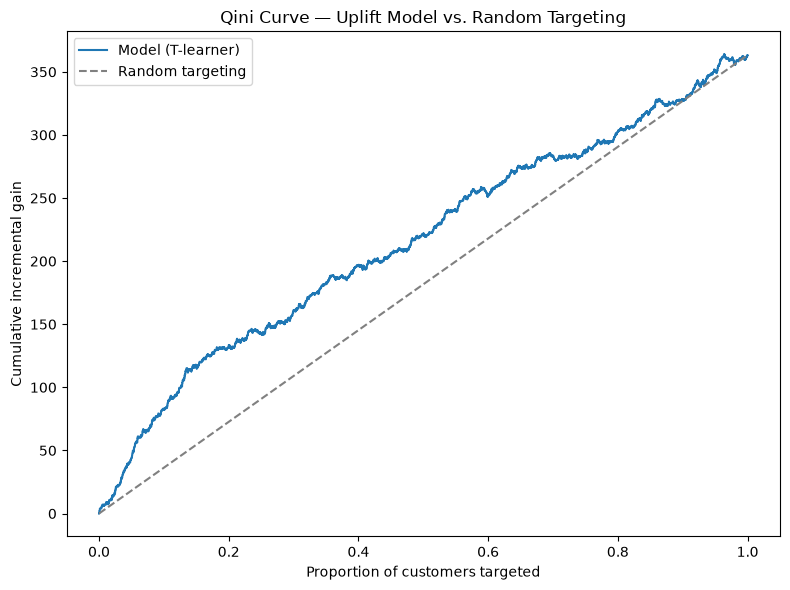

Qini coefficient: 33.8803


In [7]:
# Build an evaluation dataframe with predicted uplift and true outcomes
eval_df = pd.DataFrame({
    "predicted_uplift": predicted_uplift,
    "treatment": t_test.values,
    "outcome": y_test_u.values,
    "true_ite": true_ite_test.values,
})

# Sort by predicted uplift, descending — simulates "target the customers
# the model thinks will benefit most, first"
eval_df = eval_df.sort_values("predicted_uplift", ascending=False).reset_index(drop=True)
eval_df["population_pct"] = (np.arange(len(eval_df)) + 1) / len(eval_df)

# Cumulative incremental gain: at each point, compare cumulative outcome
# rate among treated vs. control customers seen SO FAR (in this sorted order)
eval_df["cum_treated_outcome"] = (eval_df["outcome"] * (eval_df["treatment"] == 1)).cumsum()
eval_df["cum_control_outcome"] = (eval_df["outcome"] * (eval_df["treatment"] == 0)).cumsum()
eval_df["cum_treated_n"] = (eval_df["treatment"] == 1).cumsum()
eval_df["cum_control_n"] = (eval_df["treatment"] == 0).cumsum()

# Qini value at each point: treated conversion rate minus control conversion rate,
# scaled by the number of treated customers seen so far
eval_df["qini"] = (
    eval_df["cum_treated_outcome"] / eval_df["cum_treated_n"].replace(0, np.nan)
    - eval_df["cum_control_outcome"] / eval_df["cum_control_n"].replace(0, np.nan)
) * eval_df["cum_treated_n"]
eval_df["qini"] = eval_df["qini"].fillna(0)

# Random targeting baseline: a straight line from 0 to the total observed uplift
total_uplift_effect = eval_df["qini"].iloc[-1]
random_line = eval_df["population_pct"] * total_uplift_effect

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(eval_df["population_pct"], eval_df["qini"], label="Model (T-learner)")
ax.plot(eval_df["population_pct"], random_line, linestyle="--", color="gray", label="Random targeting")
ax.set_xlabel("Proportion of customers targeted")
ax.set_ylabel("Cumulative incremental gain")
ax.set_title("Qini Curve — Uplift Model vs. Random Targeting")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/qini_curve.png", dpi=150)
plt.show()

# Qini coefficient: area between model curve and random line —
# higher is better, 0 means no better than random
qini_coefficient = np.trapezoid(eval_df["qini"] - random_line, eval_df["population_pct"])
print(f"Qini coefficient: {qini_coefficient:.4f}")

### Business translation (targeting efficiency)
Converting the Qini result into a decision-relevant question: what percentage 
of the total benefit do we capture if we only target a fraction of customers, 
ranked by predicted uplift? This shows the tradeoff between campaign cost 
(fewer customers targeted) and benefit captured, without needing an assumed 
dollar cost per discount.

In [8]:
# eval_df is already sorted by predicted_uplift descending from the Qini step.
# At each population percentage, what fraction of the TOTAL true benefit
# would we have captured if we'd only targeted that top slice?

total_true_benefit = eval_df["true_ite"].sum()  # total benefit if EVERYONE were treated optimally
eval_df["cum_true_benefit"] = eval_df["true_ite"].cumsum()
eval_df["pct_benefit_captured"] = eval_df["cum_true_benefit"] / total_true_benefit

# Check a few concrete thresholds — the kind of numbers a stakeholder would ask for
thresholds = [0.10, 0.20, 0.30, 0.50]
summary_rows = []
for t in thresholds:
    idx = int(len(eval_df) * t) - 1
    pct_captured = eval_df.loc[idx, "pct_benefit_captured"]
    summary_rows.append({
        "targeted_pct": f"{int(t*100)}%",
        "benefit_captured_pct": f"{pct_captured:.1%}"
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

targeted_pct benefit_captured_pct
         10%                25.6%
         20%                38.8%
         30%                46.9%
         50%                62.2%


### Visualizing the tradeoff
Plotting percent of customers targeted against percent of total benefit 
captured — the further above the diagonal, the more efficient targeting by 
predicted uplift is compared to targeting randomly.

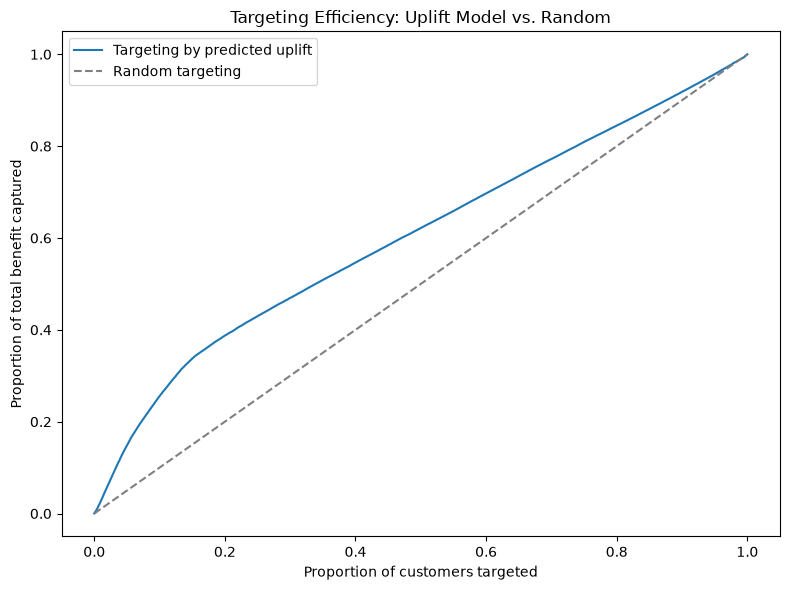

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(eval_df["population_pct"], eval_df["pct_benefit_captured"], label="Targeting by predicted uplift")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random targeting")
ax.set_xlabel("Proportion of customers targeted")
ax.set_ylabel("Proportion of total benefit captured")
ax.set_title("Targeting Efficiency: Uplift Model vs. Random")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/targeting_efficiency.png", dpi=150)
plt.show()

### Exporting data for the dashboard
Saving the customer-level uplift results and evaluation metrics so the 
Streamlit app can load them instantly instead of retraining models live.


In [10]:
import json

# Save per-customer uplift results for the dashboard to filter/display
dashboard_data = eval_df[["predicted_uplift", "treatment", "outcome", "true_ite", "population_pct", "pct_benefit_captured"]].copy()
dashboard_data.to_csv("../data/processed/dashboard_uplift_results.csv", index=False)

# Save key headline metrics as a small JSON summary
summary_metrics = {
    "n_customers_evaluated": len(eval_df),
    "qini_coefficient": float(qini_coefficient),
    "avg_predicted_uplift": float(predicted_uplift.mean()),
    "avg_true_uplift": float(true_ite_test.mean()),
    "benefit_captured_at_10pct": float(summary_df.iloc[0]["benefit_captured_pct"].strip('%')) / 100,
    "benefit_captured_at_20pct": float(summary_df.iloc[1]["benefit_captured_pct"].strip('%')) / 100,
    "benefit_captured_at_30pct": float(summary_df.iloc[2]["benefit_captured_pct"].strip('%')) / 100,
    "benefit_captured_at_50pct": float(summary_df.iloc[3]["benefit_captured_pct"].strip('%')) / 100,
    "baseline_roc_auc": 0.5727,
    "baseline_pr_auc": 0.0468,
}

with open("../data/processed/dashboard_summary.json", "w") as f:
    json.dump(summary_metrics, f, indent=2)

print("Exported dashboard_uplift_results.csv and dashboard_summary.json")
print(summary_metrics)

Exported dashboard_uplift_results.csv and dashboard_summary.json
{'n_customers_evaluated': 16772, 'qini_coefficient': 33.88025511550382, 'avg_predicted_uplift': 0.040538634809451905, 'avg_true_uplift': 0.041038491544102766, 'benefit_captured_at_10pct': 0.256, 'benefit_captured_at_20pct': 0.38799999999999996, 'benefit_captured_at_30pct': 0.469, 'benefit_captured_at_50pct': 0.622, 'baseline_roc_auc': 0.5727, 'baseline_pr_auc': 0.0468}
